# L1B observation geometry and RX bin georeferencing
Real stored instrument, RWSTART, RWSTOP and official Refh coordinates define this scene. WGS84 geodetic coordinates (EPSG:4979) are converted to ECEF (EPSG:4978) before geometry, then rotated to one local ENU frame for display.

H2 is the audit's recommended research bin-centre mapping, not an officially confirmed complete range-correction model. H1/H2 closure compares against the stored Refh and does not certify absolute secondary-peak accuracy. The aircraft glyph is schematic, anchored at the only stored instrument reference point; no lever arm is invented.

## Inputs and configuration
This notebook runs independently. The default high-quality pulse is also a canopy-context gallery candidate. Optional gallery reuse is explicit; otherwise the fixed default remains stable.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import h5py, rasterio
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'casals_l1b').is_dir():
    raise RuntimeError('Start Jupyter in the CASALS repository root.')
sys.path.insert(0, str(ROOT))
from research.showcase import *
GRANULES = sorted((ROOT / 'data/raw/casals_l1b').glob('casals_l1b_202411*T*_001_02.h5'))
if len(GRANULES) != 2:
    raise FileNotFoundError('Expected the November 12 and November 18, 2024 L1B granules in data/raw/casals_l1b.')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11, 'axes.spines.top':False,
                     'axes.spines.right':False, 'savefig.dpi':220, 'axes.titleweight':'bold'})
SEED = 42
DPI = 220
from pyproj import Transformer
from casals_l1b.waveform import build_record_index_grid, infer_waveform_record_axis, read_waveform_records
from casals_l1b.h5 import normalize_attribute
from research.geolocation.bin_georeferencing_audit.run_audit import inventory
import plotly.graph_objects as go
H5_PATH = GRANULES[1]
OUTPUT_DIR = ROOT / 'outputs/notebooks/07_georeferencing_geometry' / H5_PATH.stem
SELECTED_PULSE_INDEX = 2128614
USE_EXISTING_GALLERY_SELECTION = False
SCENE_SWEEPS = 60
TRACK_STRIDE = 16
MAIN_VERTICAL_DISPLAY_SCALE = .025  # Explicit display compression; numerical coordinates stay unchanged
RAY_SWEEP_STRIDE = 10
RAY_TRACK_STRIDE = 64
TERRAIN_STEP_M = 10.
SNR_DISPLAY_MIN = 5.
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
if USE_EXISTING_GALLERY_SELECTION:
    path=ROOT/'outputs/notebooks/06_waveform_gallery'/H5_PATH.stem/'selected_waveform_cases.json'
    if path.exists():
        SELECTED_PULSE_INDEX=int(json.loads(path.read_text())['cases'][0]['pulse_index'])


## Actual field inventory and coordinate contract
Dataset attributes are copied exactly, including absent units/description. Empty attributes are not replaced by asserted official semantics. Refh uses the current research WGS84 ellipsoidal interpretation; the same frame for RW heights and instrument altitude is an empirically supported working assumption. Realization/epoch and some corrections remain unconfirmed. There is no separately stored aircraft GNSS/IMU reference coordinate or calibrated lever arm in this scene.

RWSTART/RWSTOP are spatial endpoints of the RX receive window. They are neither aircraft positions nor necessarily surface intersections.

In [2]:
FIELD_NAMES = ['instrument_longitude','instrument_latitude','instrument_altitude',
    'rwstart_longitude','rwstart_latitude','rwstart','rwstop_longitude','rwstop_latitude','rwstop',
    'refh_longitude','refh_latitude','refh','local_beam_azimuth','local_beam_elevation',
    'sweep_num','track_num','delta_time','rx_waveform']
with h5py.File(H5_PATH,'r') as h5:
    field_inventory={name:dict(shape=list(h5[name].shape),dtype=str(h5[name].dtype),units_from_attrs=normalize_attribute(h5[name].attrs.get('units',None)),
                     attrs={k:normalize_attribute(v) for k,v in h5[name].attrs.items()},usable=True) for name in FIELD_NAMES}
    global_attrs={k:normalize_attribute(v) for k,v in h5.attrs.items()}
    ACQUISITION_DATE = global_attrs['start_utca'].split('T')[0]
    index=build_record_index_grid(h5)
    assert index.duplicate_sweep_track_cells==0
    pulse=int(SELECTED_PULSE_INDEX)
    assert 0<=pulse<index.n_records
    sweep,track=int(index.sweep_num[pulse]),int(index.track_num[pulse])
    assert index.record_index_grid[sweep,track]==pulse
    axis=infer_waveform_record_axis(h5['rx_waveform'],index.n_records)
    rx=read_waveform_records(h5['rx_waveform'],axis,[pulse])[0]
    fields={name:float(h5[name][pulse]) for name in FIELD_NAMES if name!='rx_waveform'}
    fields['refh_snr']=float(h5['refh_snr'][pulse])
working_units={name:('degrees' if name.endswith(('_longitude','_latitude')) else 'metres (working ellipsoidal convention)' if name in ['instrument_altitude','rwstart','rwstop','refh'] else 'radians (audit convention)' if name.startswith('local_beam_') else 'zero-based index' if name in ['sweep_num','track_num'] else 'raw digital counts' if name=='rx_waveform' else 'seconds relative to stored epoch (working convention)') for name in FIELD_NAMES}
for name in FIELD_NAMES: field_inventory[name]['working_units']=working_units[name]
display(pd.DataFrame([dict(field=k,shape=v['shape'],dtype=v['dtype'],units_from_attrs=v['units_from_attrs'],working_units=v['working_units'],attrs=v['attrs']) for k,v in field_inventory.items()]))
print(f'Pulse {pulse}; sweep {sweep}; track {track}; SNR {fields["refh_snr"]:.3f}; RX record axis {axis}')
save_json(OUTPUT_DIR/'h5_field_inventory.json',dict(fields=field_inventory,global_attrs=global_attrs,
    interpretation='Coordinates use a working WGS84 ellipsoidal convention; empty attrs remain unknown'))


,field,shape,dtype,units_from_attrs,working_units,attrs
0,instrument_longitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
1,instrument_latitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
2,instrument_altitude,[3604480],float64,None,metres (working ellipsoidal convention),{'DIMENSION_LIST': [[<HDF5 object reference>]]}
3,rwstart_longitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
4,rwstart_latitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
5,rwstart,[3604480],float64,None,metres (working ellipsoidal convention),{'DIMENSION_LIST': [[<HDF5 object reference>]]}
6,rwstop_longitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
7,rwstop_latitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}
8,rwstop,[3604480],float64,None,metres (working ellipsoidal convention),{'DIMENSION_LIST': [[<HDF5 object reference>]]}
9,refh_longitude,[3604480],float64,None,degrees,{'DIMENSION_LIST': [[<HDF5 object reference>]]}


Pulse 2128614; sweep 8314; track 55; SNR 9.065; RX record axis 0


## ECEF geometry and H1/H2 mapping
For zero-based bin $b$ and $N$ RX samples, the audit supplies:

$P_{H1}=P_0+\frac{b}{N-1}(P_1-P_0)$ and $P_{H2}=P_0+\frac{b+0.5}{N}(P_1-P_0)$.

These are ECEF affine formulas. No interpolation in longitude/latitude or projected elevation is substituted. The Refh local origin is fixed. A round-trip test checks the ENU rotation; line-distance residuals are reported without calling them geolocation errors. The plotted beam direction is the vector derived from instrument to stored Refh, not a newly calibrated angle model.

In [3]:
to_xyz=Transformer.from_crs(4979,4978,always_xy=True)
to_geo=Transformer.from_crs(4978,4979,always_xy=True)
def stored_xyz(prefix):
    height_key='instrument_altitude' if prefix=='instrument' else prefix
    return np.array(to_xyz.transform(fields[prefix+'_longitude'],fields[prefix+'_latitude'],fields[height_key]))
I=stored_xyz('instrument');P0=stored_xyz('rwstart');P1=stored_xyz('rwstop');R=stored_xyz('refh')
assert np.isfinite(np.vstack([I,P0,P1,R])).all() and np.isfinite(rx).all()
b=int(np.argmax(rx));N=len(rx)
H1=bin_to_xyz(P0,P1,b,N,convention='H1');H2=bin_to_xyz(P0,P1,b,N,convention='H2')
# Independent formula parity against the audit's pure function.
np.testing.assert_allclose(H1,P0+b/(N-1)*(P1-P0),rtol=0,atol=1e-9)
np.testing.assert_allclose(H2,P0+(b+.5)/N*(P1-P0),rtol=0,atol=1e-9)
origin,rotation=enu_frame(fields['refh_longitude'],fields['refh_latitude'],fields['refh'])
ecef=np.vstack([I,P0,P1,R,H1,H2]);enu=to_enu(ecef,origin,rotation)
roundtrip=float(np.max(np.linalg.norm(from_enu(enu,origin,rotation)-ecef,axis=1)))
assert roundtrip<1e-8
closure_H1=float(np.linalg.norm(H1-R));closure_H2=float(np.linalg.norm(H2-R))
assert closure_H2<.001, f'Unexpected H2 closure {closure_H2} m: investigate before plotting'
window_direction=(P1-P0)/np.linalg.norm(P1-P0)
beam_direction=(R-I)/np.linalg.norm(R-I)
line_distance=lambda x:float(np.linalg.norm((x-P0)-np.dot(x-P0,window_direction)*window_direction))
geometry_table=pd.DataFrame([dict(object=name,ecef_X_m=e[0],ecef_Y_m=e[1],ecef_Z_m=e[2],
     East_m=v[0],North_m=v[1],Up_m=v[2],longitude=g[0],latitude=g[1],ellipsoidal_height_m=g[2])
     for name,e,v,g in zip(['Instrument','RWSTART','RWSTOP','Official Refh','H1 raw argmax','H2 raw argmax'],
                           ecef,enu,np.column_stack(to_geo.transform(*ecef.T)))])
geometry_table['pulse_index']=pulse;geometry_table['sweep_num']=sweep;geometry_table['track_num']=track
geometry_table['raw_argmax_bin']=b;geometry_table['n_rx_bins']=N
geometry_table['H1_closure_m']=closure_H1;geometry_table['H2_closure_m']=closure_H2
geometry_table.to_csv(OUTPUT_DIR/'selected_pulse_geometry.csv',index=False)
print(f'H1 closure {closure_H1*1000:.6f} mm; H2 closure {closure_H2*1000:.6f} mm; round-trip {roundtrip:.3g} m')
print(f'Instrument→Refh {np.linalg.norm(R-I):.3f} m; RX window {np.linalg.norm(P1-P0):.3f} m')
display(geometry_table)


H1 closure 13.118993 mm; H2 closure 0.536639 mm; round-trip 0 m
Instrument→Refh 5511.034 m; RX window 408.804 m


,object,ecef_X_m,ecef_Y_m,ecef_Z_m,East_m,North_m,Up_m,longitude,latitude,ellipsoidal_height_m,pulse_index,sweep_num,track_num,raw_argmax_bin,n_rx_bins,H1_closure_m,H2_closure_m
0,Instrument,1.187743e+06,-5.019565e+06,3.748238e+06,220.217555,1.186852e+01,5506.619092,-76.687375,36.187445,5487.095992,2128614,8314,55,1612,2728,0.013119,0.000537
1,RWSTART,1.186561e+06,-5.015485e+06,3.745120e+06,9.655705,5.203894e-01,241.447785,-76.689714,36.187343,221.920887,2128614,8314,55,1612,2728,0.013119,0.000537
2,RWSTOP,1.186469e+06,-5.015168e+06,3.744878e+06,-6.679617,-3.599949e-01,-167.028552,-76.689895,36.187335,-186.555454,2128614,8314,55,1612,2728,0.013119,0.000537
3,Official Refh,1.186507e+06,-5.015297e+06,3.744977e+06,0.000000,0.000000e+00,0.000000,-76.689821,36.187338,-19.526905,2128614,8314,55,1612,2728,0.013119,0.000537
4,H1 raw argmax,1.186507e+06,-5.015297e+06,3.744977e+06,-0.000525,-2.845737e-05,-0.013108,-76.689821,36.187338,-19.540014,2128614,8314,55,1612,2728,0.013119,0.000537
5,H2 raw argmax,1.186507e+06,-5.015297e+06,3.744977e+06,0.000021,9.503303e-07,0.000536,-76.689821,36.187338,-19.526369,2128614,8314,55,1612,2728,0.013119,0.000537


## Scene construction and supported tentative terrain
One actual median-delta-time record represents each sweep's instrument location; these representatives are sorted by delta_time. A variation summary records within-sweep position differences. Tracks are thinned before plotting, with only a few representative rays. Refh scene points below SNR 5 are omitted from the scene display, with counts recorded; the selected geometry itself remains unchanged.

Terrain comes only from valid, supported same-granule DTM cells. Each sampled projected XY is transformed to geodetic coordinates with its tentative source ellipsoidal height, then to the same ECEF/ENU frame. No 3DEP heights or artificial plane are introduced. Missing terrain cells remain holes.

In [4]:
start=max(0,sweep-SCENE_SWEEPS//2);stop=min(index.n_sweeps,start+SCENE_SWEEPS)
sweeps=np.arange(start,stop)
scene_ids=index.record_index_grid[np.ix_(sweeps,np.arange(0,index.n_tracks,TRACK_STRIDE))].ravel()
scene_ids=scene_ids[scene_ids>=0]
representative_ids=[];variation=[]
with h5py.File(H5_PATH,'r') as h5:
    for sw in sweeps:
        row=index.record_index_grid[sw];row=row[row>=0]
        times=np.array([h5['delta_time'][i] for i in row])
        representative_ids.append(int(row[np.argsort(times,kind='stable')[len(row)//2]]))
        inst=np.column_stack([np.array([h5[n][i] for i in row]) for n in ['instrument_longitude','instrument_latitude','instrument_altitude']])
        inst_xyz=np.column_stack(to_xyz.transform(*inst.T))
        variation.append(float(np.max(np.linalg.norm(inst_xyz-inst_xyz[len(row)//2],axis=1))))
    all_ids=np.unique(np.r_[scene_ids,representative_ids])
    scene_fields={n:np.asarray(h5[n][all_ids]) for n in ['instrument_longitude','instrument_latitude','instrument_altitude',
        'refh_longitude','refh_latitude','refh','refh_snr','delta_time']}
positions=np.column_stack(to_xyz.transform(scene_fields['instrument_longitude'],scene_fields['instrument_latitude'],scene_fields['instrument_altitude']))
returns=np.column_stack(to_xyz.transform(scene_fields['refh_longitude'],scene_fields['refh_latitude'],scene_fields['refh']))
inst_enu=to_enu(positions,origin,rotation);ref_enu=to_enu(returns,origin,rotation)
trajectory_rows=np.searchsorted(all_ids,representative_ids)
trajectory_rows=trajectory_rows[np.argsort(scene_fields['delta_time'][trajectory_rows],kind='stable')]
trajectory=inst_enu[trajectory_rows]
show_rows=np.searchsorted(all_ids,scene_ids)
show_rows=show_rows[np.isfinite(ref_enu[show_rows]).all(axis=1)&(scene_fields['refh_snr'][show_rows]>=SNR_DISPLAY_MIN)]
ray_ids=index.record_index_grid[np.ix_(sweeps[::RAY_SWEEP_STRIDE],np.arange(0,index.n_tracks,RAY_TRACK_STRIDE))].ravel()
ray_ids=ray_ids[ray_ids>=0];ray_rows=np.searchsorted(all_ids,ray_ids)
ray_rows=ray_rows[(scene_fields['refh_snr'][ray_rows]>=SNR_DISPLAY_MIN)&np.isfinite(ref_enu[ray_rows]).all(axis=1)]
try:
    terrain_products,terrain_metadata=find_products(H5_PATH,'dtm_tif')
except FileNotFoundError:
    _,terrain_products,_=ensure_surfaces(H5_PATH,OUTPUT_DIR)
    terrain_products,terrain_metadata=find_products(H5_PATH,'dtm_tif')
utm=Transformer.from_crs(4326,32618,always_xy=True)
scene_xy=np.column_stack(utm.transform(scene_fields['refh_longitude'][show_rows],scene_fields['refh_latitude'][show_rows]))
grid_x=np.arange(np.floor(scene_xy[:,0].min()/TERRAIN_STEP_M)*TERRAIN_STEP_M-20,scene_xy[:,0].max()+30,TERRAIN_STEP_M)
grid_y=np.arange(np.floor(scene_xy[:,1].min()/TERRAIN_STEP_M)*TERRAIN_STEP_M-20,scene_xy[:,1].max()+30,TERRAIN_STEP_M)
xx,yy=np.meshgrid(grid_x,grid_y);terrain_xy=np.column_stack([xx.ravel(),yy.ravel()])
heights,supported=sample_raster(terrain_products['dtm_tif'],terrain_xy,32618,terrain_products['support_mask_tif'])
lo,la=Transformer.from_crs(32618,4326,always_xy=True).transform(*terrain_xy.T)
terrain_xyz=np.column_stack(to_xyz.transform(lo,la,heights));terrain_enu=to_enu(terrain_xyz,origin,rotation).reshape(*xx.shape,3)
assert supported.any()
print(f'{len(trajectory)} actual sweep representatives; {len(show_rows)} displayed Refh; {len(ray_rows)} rays; {supported.sum()} supported terrain samples')


60 actual sweep representatives; 129 displayed Refh; 4 rays; 117 supported terrain samples


## Scene-level 3D figures
The full altitude view explicitly uses vertical display scale **0.025×** (horizontal-to-vertical ratio 40:1), so the narrow swath is legible beneath the 5.5 km instrument altitude. Numerical coordinates stay unchanged. The surface zoom uses equal physical metre scale. Aircraft strokes are a schematic glyph at the real instrument position, not a second measured coordinate. HTML embeds Plotly locally.

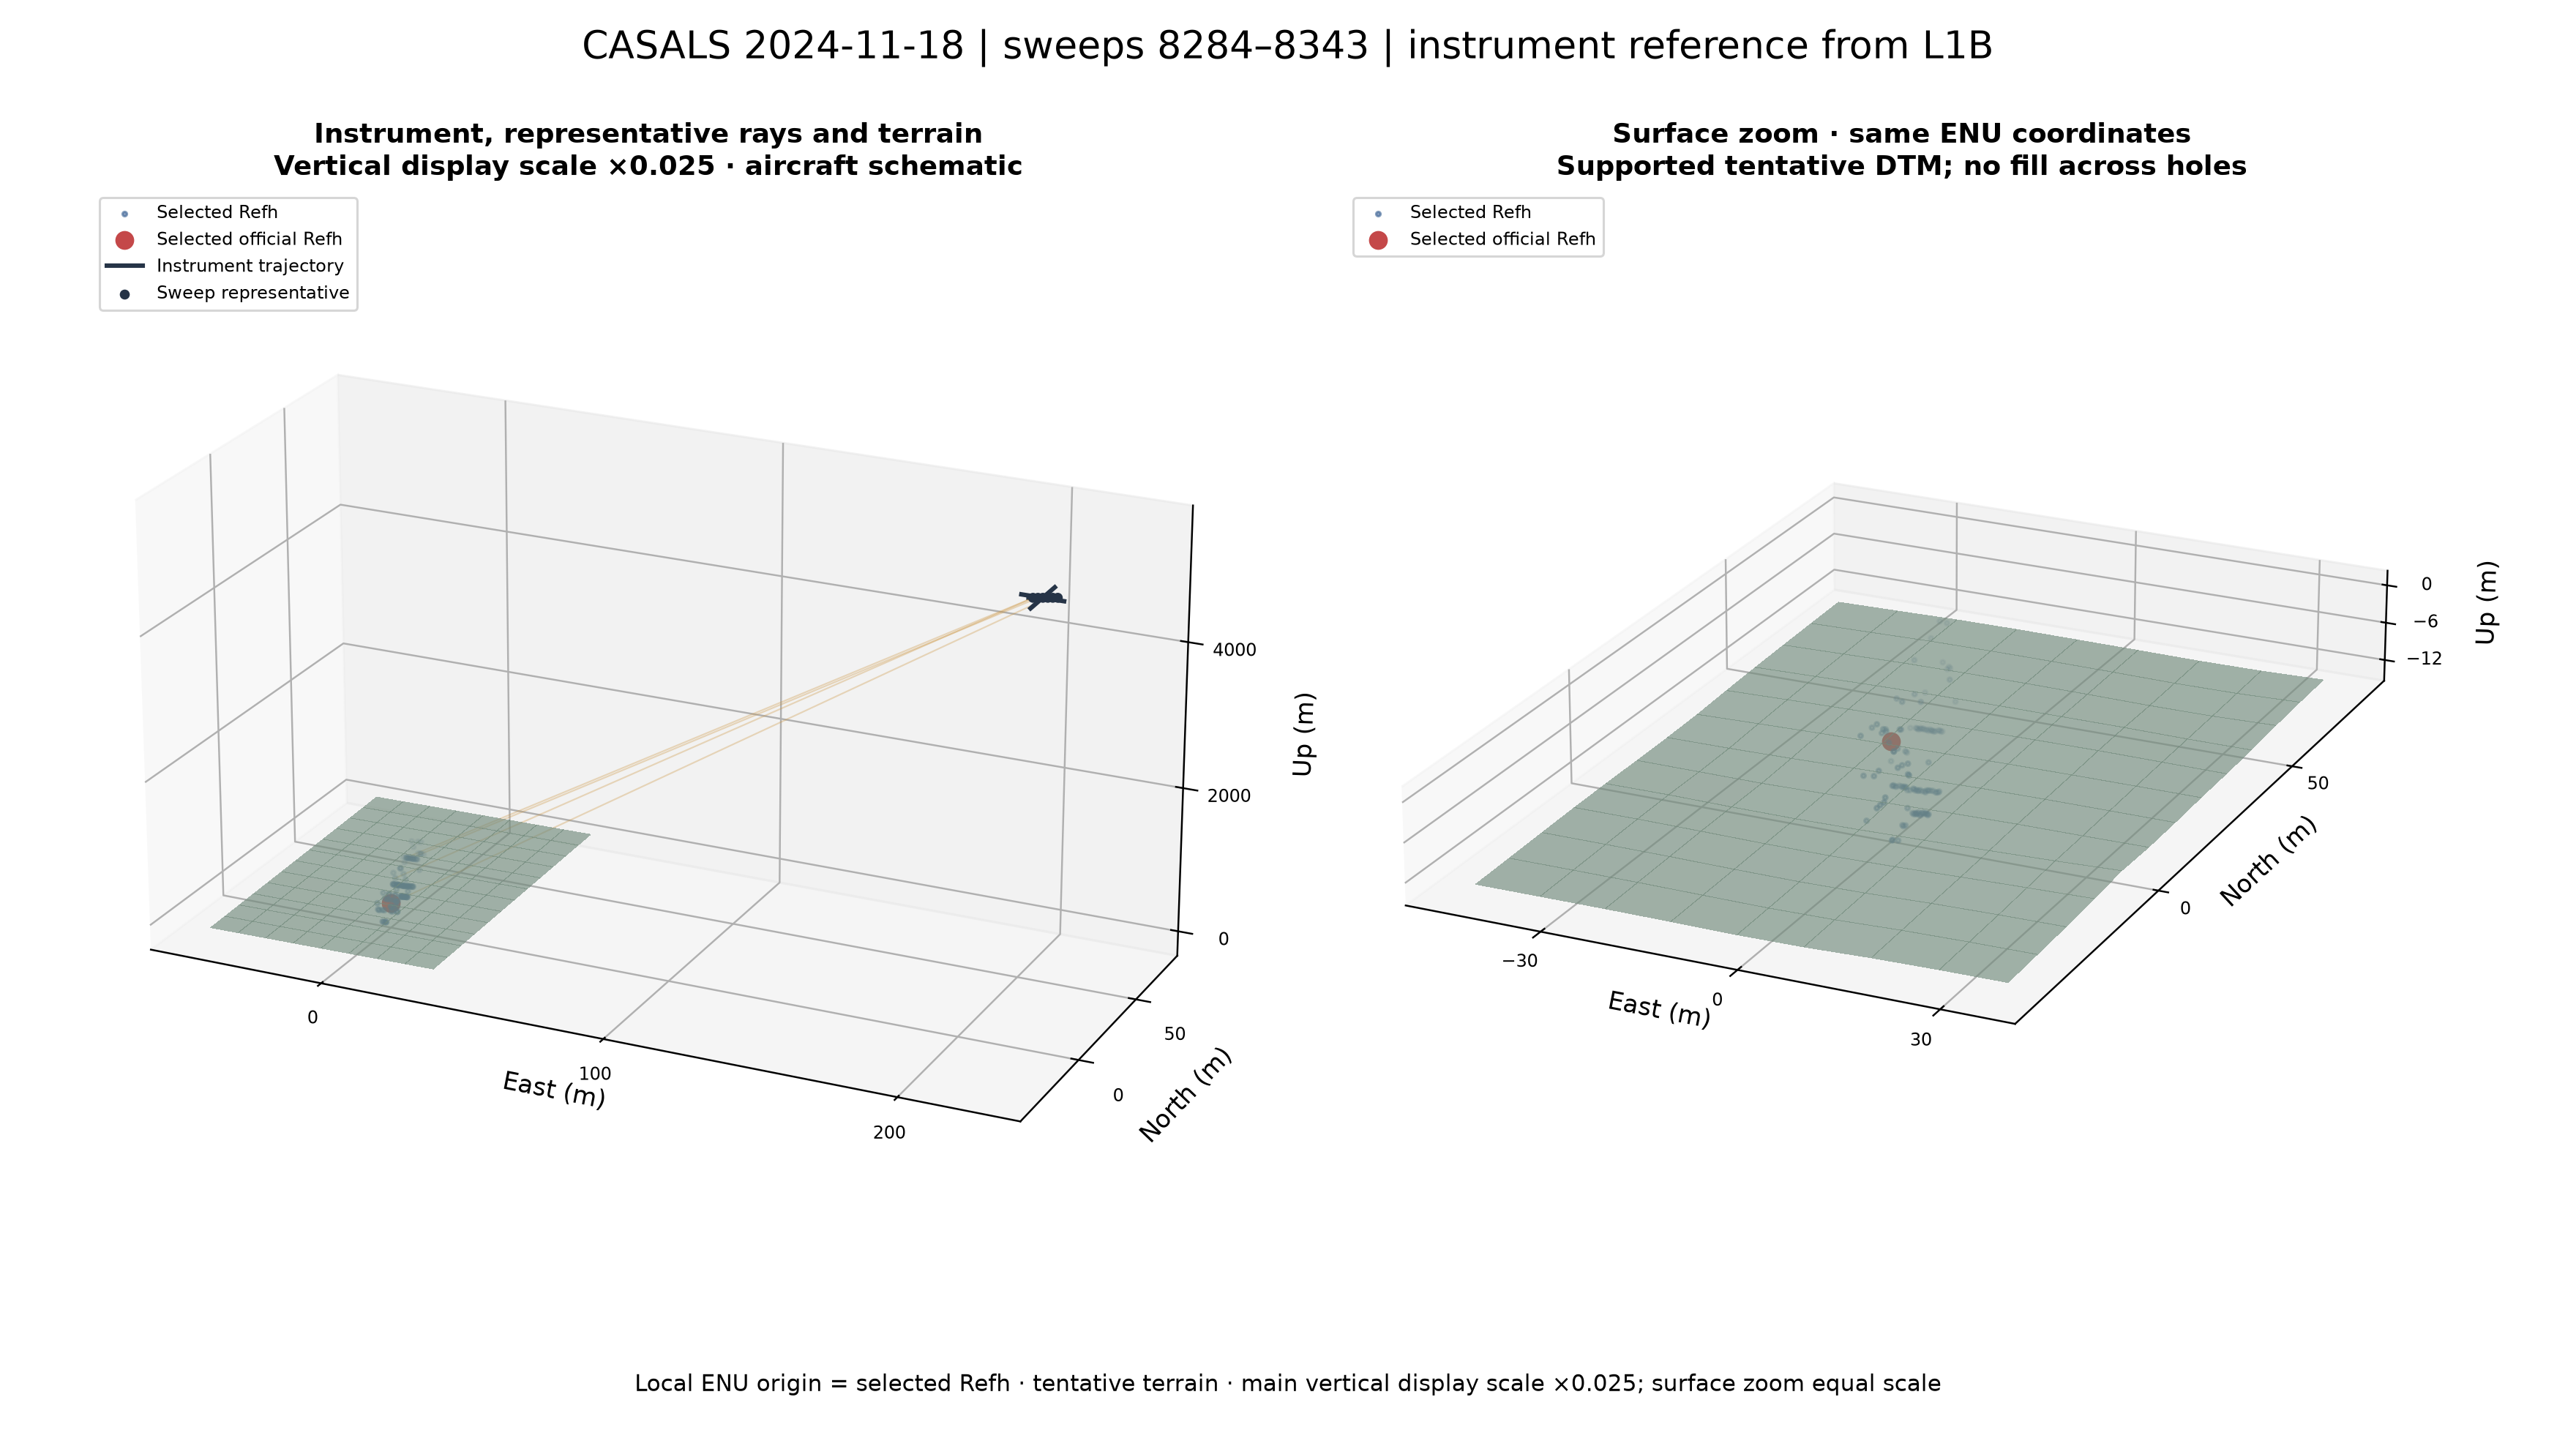

In [5]:
Iu,P0u,P1u,Ru,H1u,H2u=enu
def axes3d(ax,data,vertical_display_scale=1.):
    data=np.asarray(data);data=data[np.isfinite(data).all(axis=1)]
    low=data.min(axis=0);high=data.max(axis=0);span=np.maximum(high-low,1)
    ax.set_xlim(low[0]-span[0]*.06,high[0]+span[0]*.06)
    ax.set_ylim(low[1]-span[1]*.06,high[1]+span[1]*.06)
    ax.set_zlim(low[2]-span[2]*.06,high[2]+span[2]*.06)
    ax.set_box_aspect(span*np.array([1,1,vertical_display_scale]));ax.view_init(elev=22,azim=-65)
    from matplotlib.ticker import MaxNLocator
    for axis in [ax.xaxis,ax.yaxis,ax.zaxis]: axis.set_major_locator(MaxNLocator(3))
    ax.set_xlabel('East (m)');ax.set_ylabel('North (m)');ax.set_zlabel('Up (m)')
    ax.tick_params(labelsize=8);ax.zaxis.labelpad=9
def terrain_mpl(ax):
    ax.plot_surface(terrain_enu[:,:,0],terrain_enu[:,:,1],terrain_enu[:,:,2],color='#95b5a2',alpha=.65,
                    linewidth=0,antialiased=False,rstride=1,cstride=1)
def aircraft_glyph(ax,anchor):
    # Wing/fuselage strokes are schematic, anchored to the instrument; no lever arm.
    ax.plot([anchor[0]-7,anchor[0]+7],[anchor[1]]*2,[anchor[2]]*2,c='#263447',lw=2)
    ax.plot([anchor[0]]*2,[anchor[1]-10,anchor[1]+10],[anchor[2]]*2,c='#263447',lw=2)
fig=plt.figure(figsize=(16,9));a=fig.add_subplot(121,projection='3d');z=fig.add_subplot(122,projection='3d')
terrain_mpl(a);terrain_mpl(z)
for ax in [a,z]:
    ax.scatter(*ref_enu[show_rows].T,c='#466b9a',s=4,alpha=.65,label='Selected Refh')
    ax.scatter(*Ru,c='#c44849',s=55,label='Selected official Refh',depthshade=False)
a.plot(*trajectory.T,c='#263447',lw=2,label='Instrument trajectory')
a.scatter(*trajectory[::10].T,c='#263447',s=12,label='Sweep representative')
for k in ray_rows:
    a.plot(*np.vstack([inst_enu[k],ref_enu[k]]).T,c='#cf9a49',alpha=.35,lw=.7)
aircraft_glyph(a,Iu)
finite_terrain=terrain_enu.reshape(-1,3)[supported]
axes3d(a,np.vstack([trajectory,ref_enu[show_rows],finite_terrain]),MAIN_VERTICAL_DISPLAY_SCALE);axes3d(z,np.vstack([ref_enu[show_rows],finite_terrain]))
a.set_title('Instrument, representative rays and terrain\nVertical display scale ×0.025 · aircraft schematic',fontsize=12)
z.set_title('Surface zoom · same ENU coordinates\nSupported tentative DTM; no fill across holes',fontsize=12)
a.legend(loc='upper left',fontsize=8);z.legend(loc='upper left',fontsize=8)
fig.suptitle(f'CASALS {ACQUISITION_DATE} | sweeps {start}–{stop-1} | instrument reference from L1B',fontsize=17)
fig.text(.5,.04,'Local ENU origin = selected Refh · tentative terrain · main vertical display scale ×0.025; surface zoom equal scale',ha='center',fontsize=10)
fig.subplots_adjust(left=.02,right=.97,bottom=.1,top=.87,wspace=.05)
fig.savefig(OUTPUT_DIR/'scene_geometry_3d.png',dpi=DPI);plt.close(fig)
scene=go.Figure()
scene.add_trace(go.Surface(x=terrain_enu[:,:,0],y=terrain_enu[:,:,1],z=terrain_enu[:,:,2],
                           colorscale=[[0,'#95b5a2'],[1,'#95b5a2']],showscale=False,opacity=.65,name='Tentative DTM',connectgaps=False))
scene.add_trace(go.Scatter3d(x=trajectory[:,0],y=trajectory[:,1],z=trajectory[:,2],mode='lines+markers',name='Instrument trajectory',line=dict(color='#263447'),marker=dict(size=2)))
scene.add_trace(go.Scatter3d(x=ref_enu[show_rows,0],y=ref_enu[show_rows,1],z=ref_enu[show_rows,2],mode='markers',name='Selected Refh',marker=dict(size=2,color='#466b9a')))
lines=[]
for k in ray_rows: lines.extend([inst_enu[k],ref_enu[k],[np.nan]*3])
lines=np.asarray(lines).reshape(-1,3)
scene.add_trace(go.Scatter3d(x=lines[:,0],y=lines[:,1],z=lines[:,2],mode='lines',name='Sampled observation rays',line=dict(color='#cf9a49',width=2),connectgaps=False))
scene.add_trace(go.Scatter3d(x=[Iu[0]],y=[Iu[1]],z=[Iu[2]],mode='markers+text',name='Instrument reference',
    text=['Aircraft schematic — instrument location from L1B'],marker=dict(size=6,color='#263447')))
scene.update_layout(title='CASALS scene | true ENU coordinates; vertical display scale ×0.025; tentative terrain',
                     scene=dict(aspectmode='data',xaxis_title='East (m)',yaxis_title='North (m)',zaxis_title='Up (m)'),margin=dict(l=0,r=0,b=0,t=60))
scene_span=np.ptp(np.vstack([trajectory,ref_enu[show_rows],finite_terrain]),axis=0)*np.array([1,1,MAIN_VERTICAL_DISPLAY_SCALE])
scene.update_layout(scene=dict(aspectmode='manual',aspectratio=dict(zip(['x','y','z'],scene_span/scene_span.max()))))
scene.write_html(OUTPUT_DIR/'scene_geometry_3d.html',include_plotlyjs=True,full_html=True)
display(Image(filename=str(OUTPUT_DIR/'scene_geometry_3d.png')))


## Single-pulse geometry and centimetre-scale closure view
The main view contains actual stored positions and the complete RX window with explicit vertical display scale **0.025×**. A separate equal-metre-scale window view shows how the receive segment extends above and below the tentative surface; its endpoints are not terrain intersections. H1/H2 markers are nearly coincident with Refh at beam scale.

The third view uses **centimetres relative to Refh**; it is a labelled local view, not an exaggeration of the main beam. H1/H2 coordinates are unchanged. The instrument-to-Refh arrow is derived from actual coordinates and not forced to align the RW endpoints.

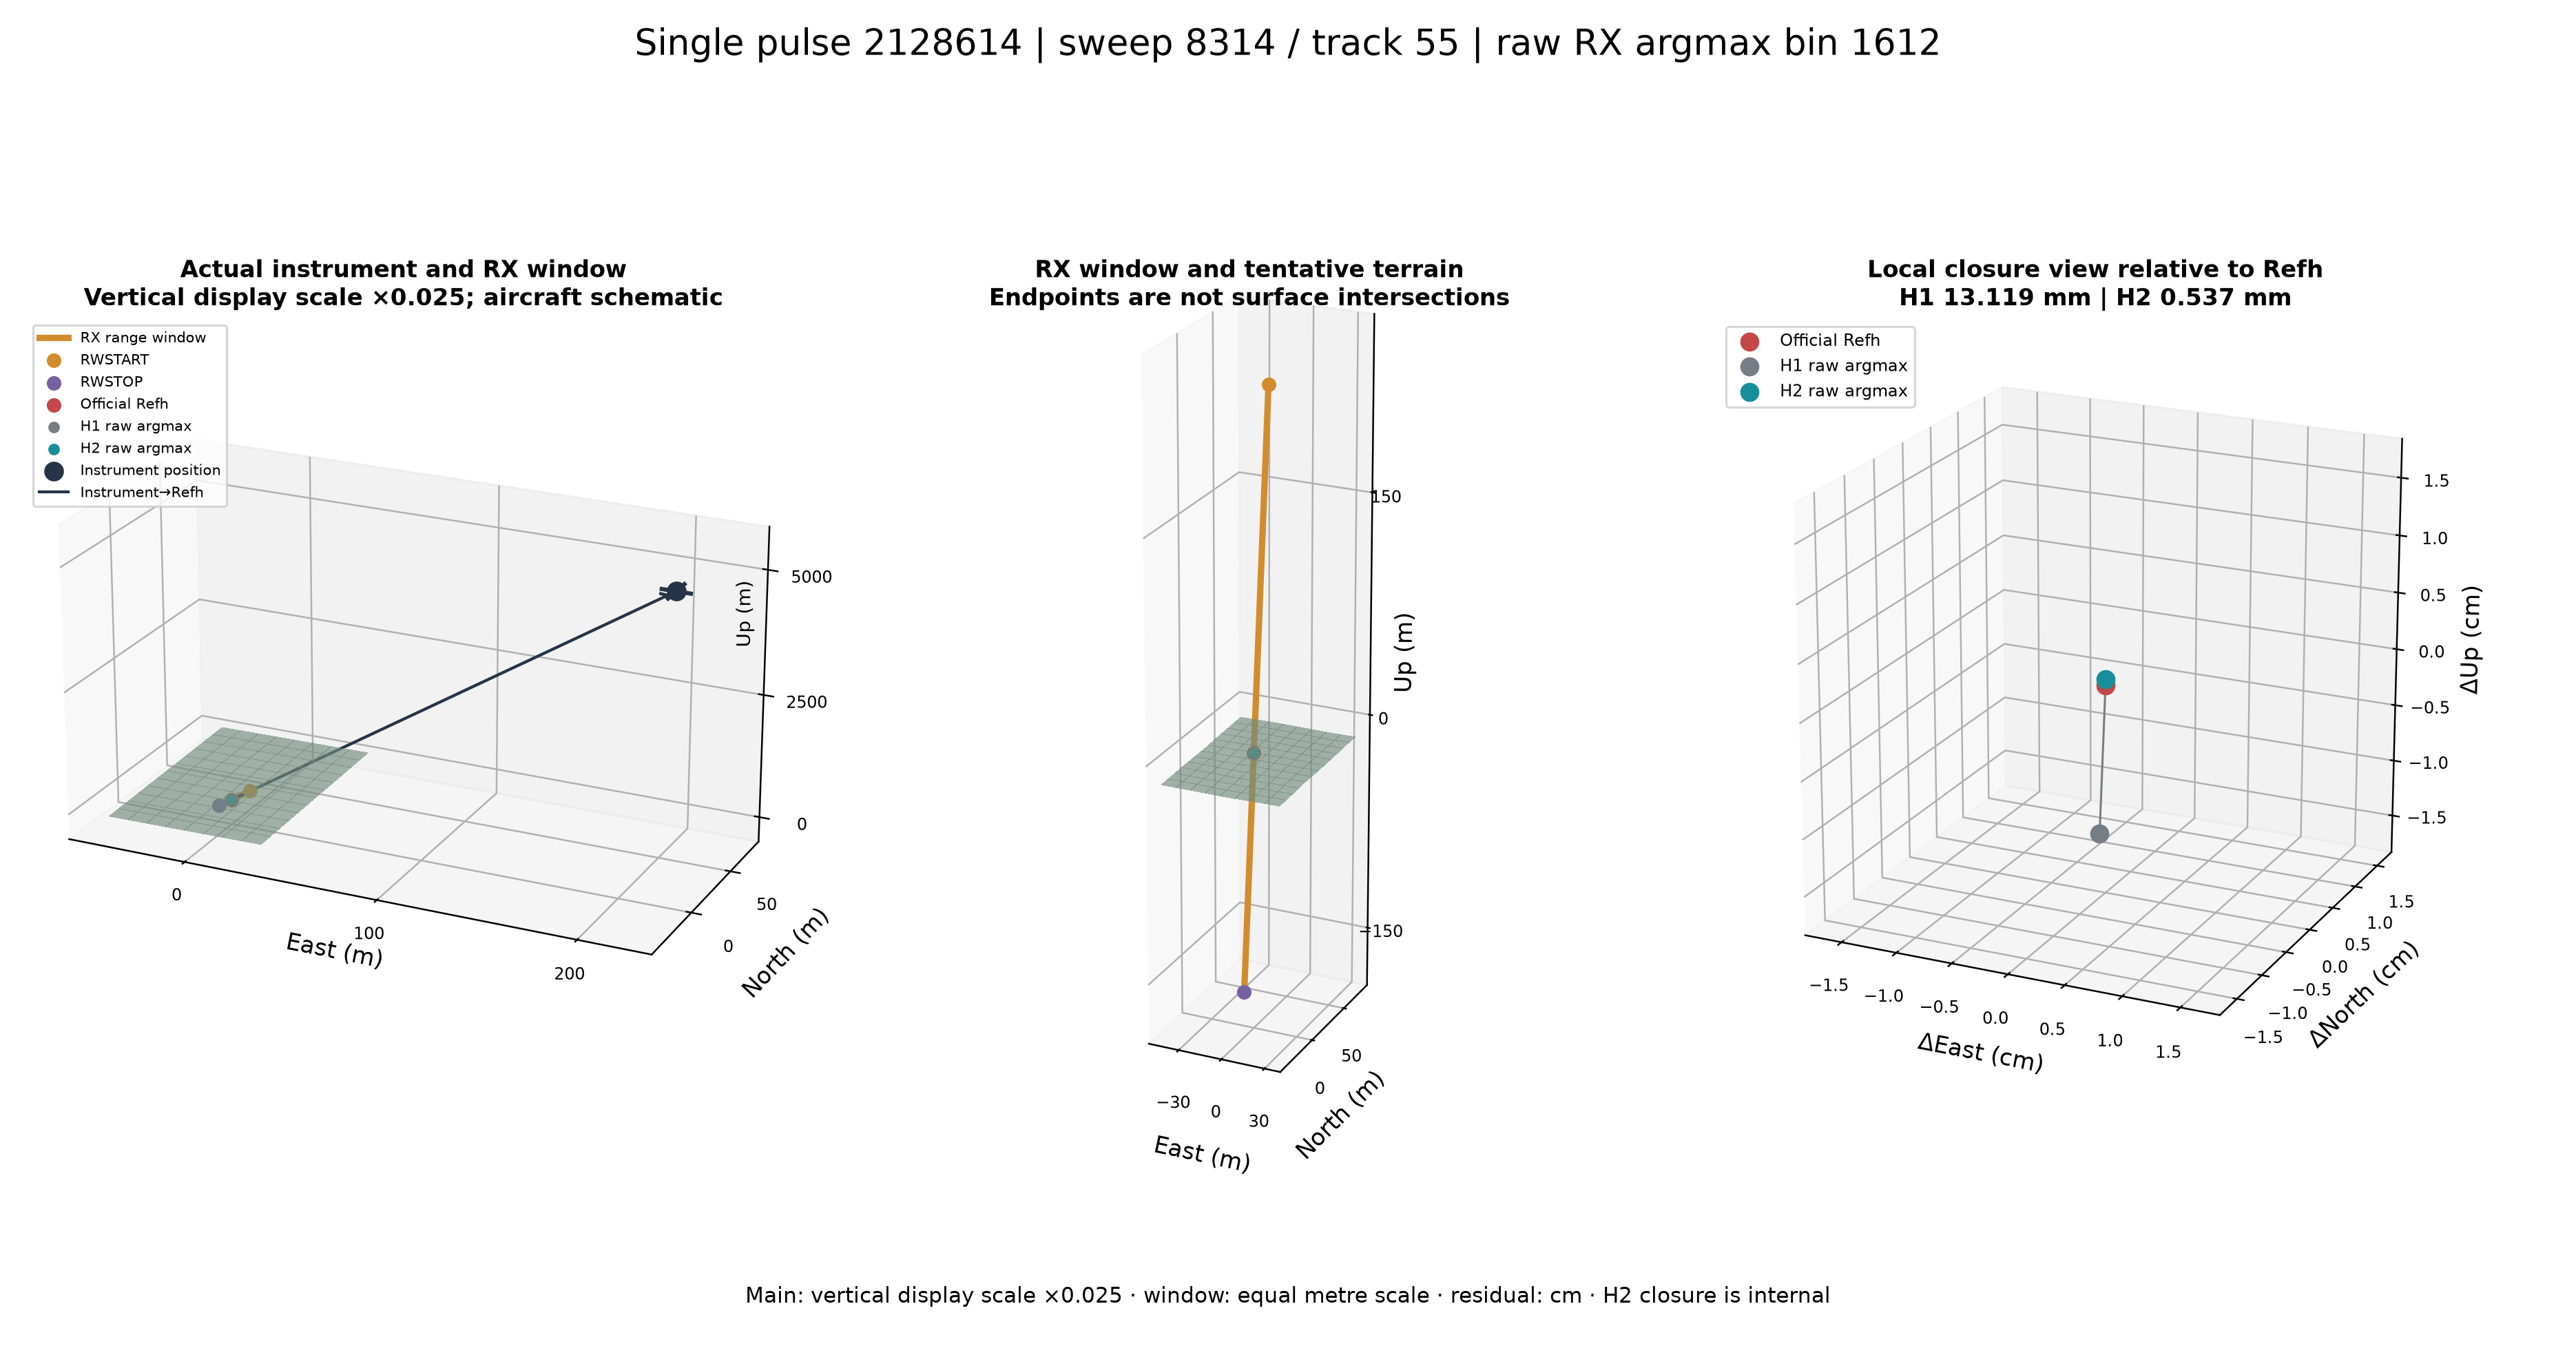

In [6]:
colors=['#263447','#d38c2d','#7662a1','#c44849','#777d85','#168e9b']
labels=['Instrument position','RWSTART','RWSTOP','Official Refh','H1 raw argmax','H2 raw argmax']
fig=plt.figure(figsize=(17,9));a=fig.add_subplot(131,projection='3d');w=fig.add_subplot(132,projection='3d');c=fig.add_subplot(133,projection='3d')
for ax in [a,w]:
    terrain_mpl(ax)
    ax.plot(*np.vstack([P0u,P1u]).T,c='#d38c2d',lw=3,label='RX range window')
    for j in range(1,6):
        ax.scatter(*enu[j],c=colors[j],s=35 if j<4 else 20,label=labels[j],depthshade=False)
a.scatter(*Iu,c=colors[0],s=70,label=labels[0],depthshade=False);aircraft_glyph(a,Iu)
a.plot(*np.vstack([Iu,Ru]).T,c='#263447',lw=1.4,label='Instrument→Refh')
direction=(Ru-Iu)/np.linalg.norm(Ru-Iu)
a.quiver(*Iu,*(direction*100),color='#263447',arrow_length_ratio=.18)
axes3d(a,np.vstack([enu,finite_terrain]),MAIN_VERTICAL_DISPLAY_SCALE);axes3d(w,np.vstack([enu[1:],finite_terrain]))
offsets=enu[3:]*100
for j in range(3):
    c.scatter(*offsets[j],c=colors[j+3],s=65,label=labels[j+3],depthshade=False)
    c.plot(*np.vstack([np.zeros(3),offsets[j]]).T,c=colors[j+3],lw=1)
span=max(np.max(np.abs(offsets)),.1)*1.4
c.set_xlim(-span,span);c.set_ylim(-span,span);c.set_zlim(-span,span);c.set_box_aspect([1,1,1]);c.view_init(elev=20,azim=-65)
c.set_xlabel('ΔEast (cm)');c.set_ylabel('ΔNorth (cm)');c.set_zlabel('ΔUp (cm)');c.tick_params(labelsize=8)
a.set_title('Actual instrument and RX window\nVertical display scale ×0.025; aircraft schematic',fontsize=11)
w.set_title('RX window and tentative terrain\nEndpoints are not surface intersections',fontsize=11)
c.set_title(f'Local closure view relative to Refh\nH1 {closure_H1*1000:.3f} mm | H2 {closure_H2*1000:.3f} mm',fontsize=11)
a.set_zlabel('')
a.text2D(.94,.57,'Up (m)',transform=a.transAxes,rotation=90,fontsize=9)
a.legend(loc='upper left',fontsize=7);c.legend(loc='upper left',fontsize=8)
fig.suptitle(f'Single pulse {pulse} | sweep {sweep} / track {track} | raw RX argmax bin {b}',fontsize=17)
fig.text(.5,.045,'Main: vertical display scale ×0.025 · window: equal metre scale · residual: cm · H2 closure is internal',ha='center',fontsize=10)
fig.subplots_adjust(left=.01,right=.96,bottom=.12,top=.86,wspace=.12)
fig.savefig(OUTPUT_DIR/'single_pulse_geometry_3d.png',dpi=DPI);plt.close(fig)
single=go.Figure()
single.add_trace(go.Surface(x=terrain_enu[:,:,0],y=terrain_enu[:,:,1],z=terrain_enu[:,:,2],colorscale=[[0,'#95b5a2'],[1,'#95b5a2']],showscale=False,opacity=.6,connectgaps=False,name='Tentative DTM'))
for name,arr,col in [('Instrument→Refh',np.vstack([Iu,Ru]),'#263447'),('RX window',np.vstack([P0u,P1u]),'#d38c2d')]:
    single.add_trace(go.Scatter3d(x=arr[:,0],y=arr[:,1],z=arr[:,2],mode='lines',name=name,line=dict(color=col,width=4)))
for j,(name,col) in enumerate(zip(labels,colors)):
    single.add_trace(go.Scatter3d(x=[enu[j,0]],y=[enu[j,1]],z=[enu[j,2]],mode='markers',name=name,marker=dict(size=5,color=col),
                    hovertemplate=name+'<br>East=%{x:.6f} m<br>North=%{y:.6f} m<br>Up=%{z:.6f} m<extra></extra>'))
single.update_layout(title=f'Pulse {pulse} | H1 {closure_H1*1000:.3f} mm / H2 {closure_H2*1000:.3f} mm internal closure; instrument is sole airborne reference',
     scene=dict(aspectmode='data',xaxis_title='East (m)',yaxis_title='North (m)',zaxis_title='Up (m)'),margin=dict(l=0,r=0,b=0,t=70))
single_span=np.ptp(np.vstack([enu,finite_terrain]),axis=0)*np.array([1,1,MAIN_VERTICAL_DISPLAY_SCALE])
single.update_layout(scene=dict(aspectmode='manual',aspectratio=dict(zip(['x','y','z'],single_span/single_span.max()))))
single.update_layout(title=single.layout.title.text+' | vertical display scale ×0.025')
single.write_html(OUTPUT_DIR/'single_pulse_geometry_3d.html',include_plotlyjs=True,full_html=True)
display(Image(filename=str(OUTPUT_DIR/'single_pulse_geometry_3d.png')))


## Two-dimensional vertical-plane explanation
Define a vertical plane through the instrument with horizontal unit direction from the instrument to Refh. Horizontal axis is the ENU horizontal displacement projected onto that unit direction; vertical axis is local Up. Off-plane distances are saved, since projected distances need not equal 3D distances. Full geometry explicitly uses vertical display scale 0.025×; the RX-window view retains equal metre scale. The waveform below uses actual raw samples and zero-based bins.

The DTM section is sampled only where supported and converted through ECEF. It provides tentative scene context, not a independently verified intersection.

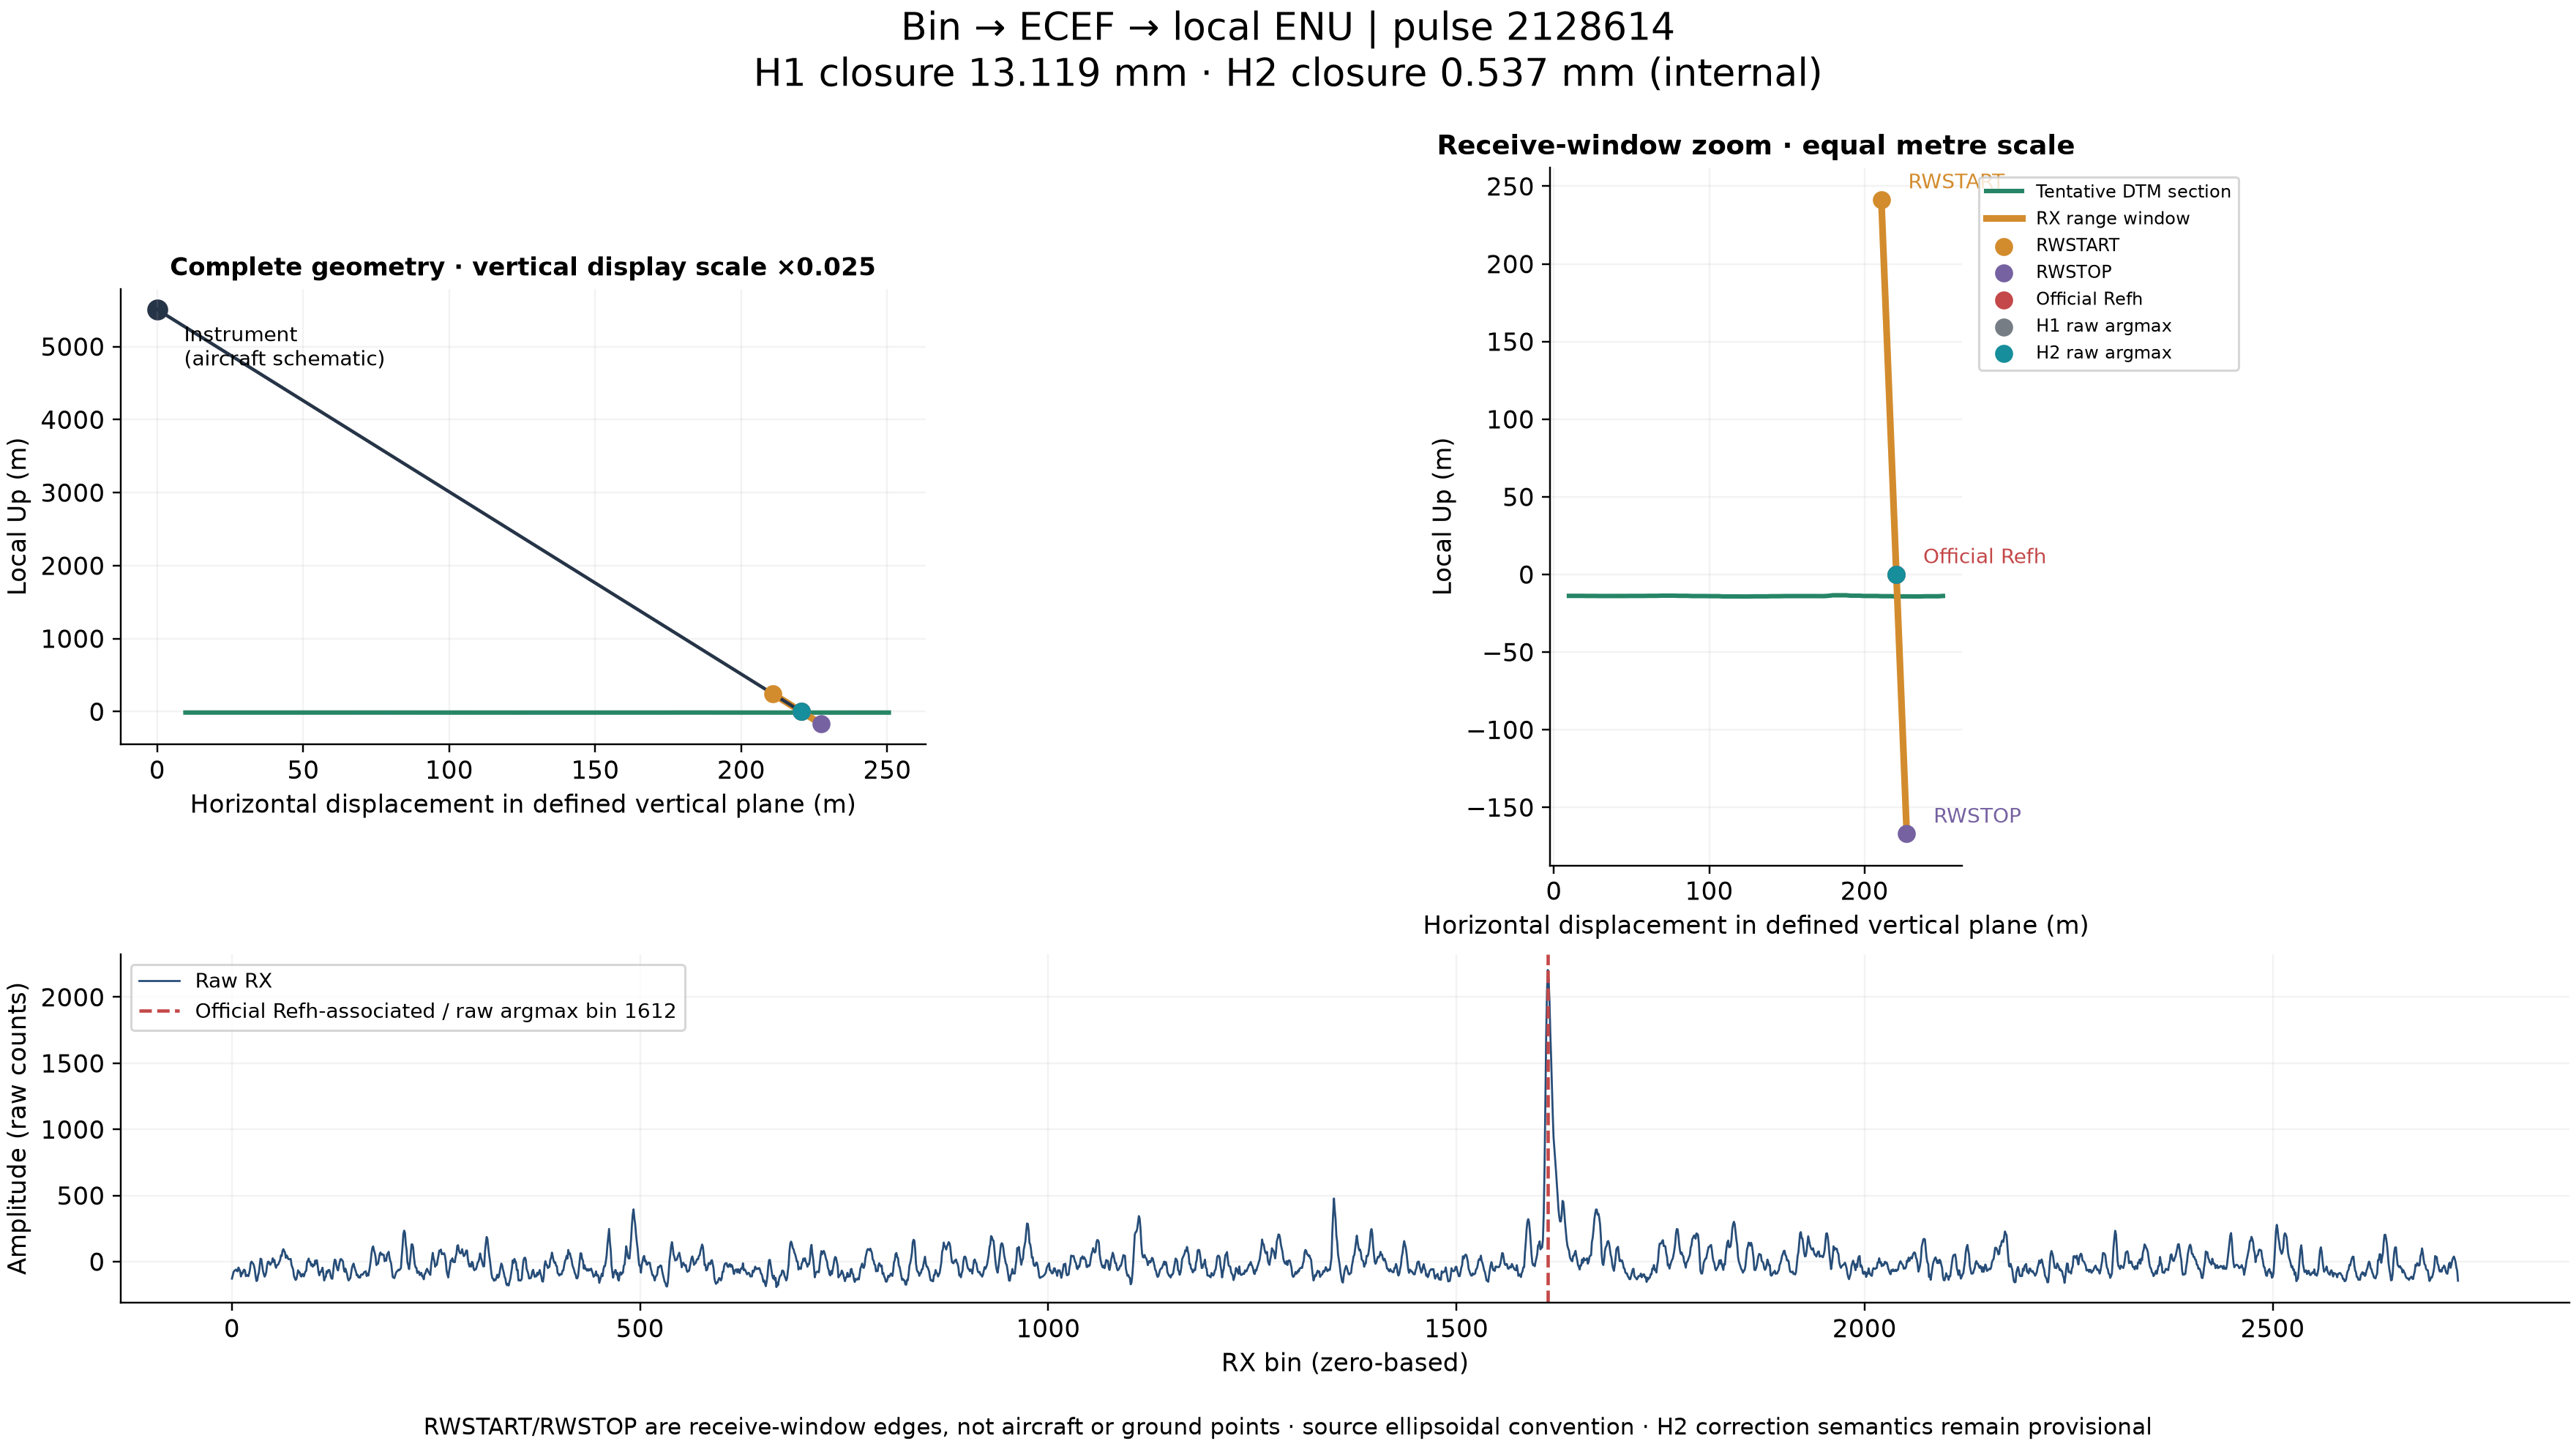

In [7]:
horizontal=Ru[:2]-Iu[:2];horizontal=horizontal/np.linalg.norm(horizontal)
def plane_coordinates(arr):
    arr=np.asarray(arr);return np.column_stack([(arr[:,:2]-Iu[:2])@horizontal,arr[:,2]])
section2d=plane_coordinates(enu)
offplane=np.abs((enu[:,:2]-Iu[:2])@np.array([-horizontal[1],horizontal[0]]))
q=np.linspace(-30,section2d[3,0]+30,100)
section_enu=np.column_stack([Iu[0]+q*horizontal[0],Iu[1]+q*horizontal[1],np.zeros(len(q))])
guess_xyz=from_enu(section_enu,origin,rotation)
glo,gla,_=to_geo.transform(*guess_xyz.T)
gx,gy=utm.transform(glo,gla)
terrain_section_h,tv=sample_raster(terrain_products['dtm_tif'],np.column_stack([gx,gy]),32618,terrain_products['support_mask_tif'])
section_xyz=np.column_stack(to_xyz.transform(glo,gla,terrain_section_h))
terrain_section=plane_coordinates(to_enu(section_xyz,origin,rotation))
fig=plt.figure(figsize=(16,9),layout='constrained');fig.get_layout_engine().set(rect=(0,.045,1,.94))
gs=fig.add_gridspec(2,3,height_ratios=[2,1]);a=fig.add_subplot(gs[0,0]);w=fig.add_subplot(gs[0,1:]);wave=fig.add_subplot(gs[1,:])
for ax in [a,w]:
    ax.plot(*terrain_section.T,c='#268566',lw=2,label='Tentative DTM section')
    ax.plot(*section2d[[1,2]].T,c='#d38c2d',lw=3,label='RX range window')
    for j in range(1,6):
        ax.scatter(*section2d[j],c=colors[j],s=50,label=labels[j],zorder=4)
    ax.set_xlabel('Horizontal displacement in defined vertical plane (m)');ax.set_ylabel('Local Up (m)')
    ax.set_aspect('equal',adjustable='box');ax.grid(alpha=.15)
a.plot(*section2d[[0,3]].T,c='#263447',lw=1.5);a.scatter(*section2d[0],c=colors[0],s=70)
a.annotate('Instrument\n(aircraft schematic)',section2d[0],xytext=(12,-25),textcoords='offset points',fontsize=9)
a.set_aspect(MAIN_VERTICAL_DISPLAY_SCALE,adjustable='box')
a.set_title('Complete geometry · vertical display scale ×0.025',fontsize=11)
w.set_title('Receive-window zoom · equal metre scale',fontsize=12)
w.legend(loc='upper left',bbox_to_anchor=(1.02,1),fontsize=8)
for j in [1,2,3]:
    w.annotate(labels[j],section2d[j],xytext=(12,5),textcoords='offset points',fontsize=9,color=colors[j])
wave.plot(np.arange(N),rx,c='#274d78',lw=.9,label='Raw RX')
wave.axvline(b,c='#c44849',ls='--',label=f'Official Refh-associated / raw argmax bin {b}')
wave.set_xlabel('RX bin (zero-based)');wave.set_ylabel('Amplitude (raw counts)');wave.legend(loc='upper left',fontsize=9);wave.grid(alpha=.15)
fig.suptitle(f'Bin → ECEF → local ENU | pulse {pulse}\nH1 closure {closure_H1*1000:.3f} mm · H2 closure {closure_H2*1000:.3f} mm (internal)',fontsize=17)
fig.text(.5,.01,'RWSTART/RWSTOP are receive-window edges, not aircraft or ground points · source ellipsoidal convention · H2 correction semantics remain provisional',ha='center',fontsize=10)
fig.savefig(OUTPUT_DIR/'bin_georeferencing_explanation.png',dpi=DPI);plt.close(fig)
display(Image(filename=str(OUTPUT_DIR/'bin_georeferencing_explanation.png')))


## Interpretation and limitations
Stored window coordinates, the raw RX argmax and H2 agree within the audit's observed sub-millimetre internal closure range. This is strong internal consistency, not external accuracy. Non-collinearity and correction residuals are reported without calibrating or deleting them.

Instrument altitude and RW heights use a working ellipsoidal convention; full official field semantics, realization/epoch, range bias and neutral-atmosphere correction application remain unresolved. An aircraft icon has no independent coordinate. Tentative DTM is not ground truth. No conclusions about absolute geolocation accuracy of arbitrary secondary components are made.

In [8]:
metadata=dict(h5=relative(H5_PATH),pulse_index=pulse,sweep_num=sweep,track_num=track,
    fields=fields,field_inventory=relative(OUTPUT_DIR/'h5_field_inventory.json'),
    origin_geodetic=[fields['refh_longitude'],fields['refh_latitude'],fields['refh']],origin_ecef=origin,enu_rotation=rotation,
    frames=['EPSG:4979','EPSG:4978','local ENU'],vertical_reference='Working WGS84 ellipsoidal convention; realization/epoch unconfirmed',
    raw_argmax_bin=b,n_rx_bins=N,H1_closure_m=closure_H1,H2_closure_m=closure_H2,
    ecef_enu_roundtrip_max_m=roundtrip,instrument_to_refh_m=float(np.linalg.norm(R-I)),
    window_length_m=float(np.linalg.norm(P1-P0)),instrument_to_rwstart_m=float(np.linalg.norm(P0-I)),
    instrument_to_rwstop_m=float(np.linalg.norm(P1-I)),refh_to_window_line_m=line_distance(R),instrument_to_window_line_m=line_distance(I),
    derived_beam_direction_ecef=beam_direction,plane_horizontal_direction_enu=horizontal,
    plane_offplane_distances_m=dict(zip(labels,offplane.tolist())),scene_sweeps=[int(start),int(stop-1)],
    scene_display_refh=len(show_rows),scene_excluded_low_snr=int(len(scene_ids)-len(show_rows)),ray_count=len(ray_rows),
    trajectory_method='One actual median-delta-time record per sweep; sorted by delta_time',
    within_sweep_instrument_max_variation_m=max(variation),terrain_metadata=relative(terrain_metadata),
    terrain_supported_samples=int(supported.sum()),terrain_total_samples=len(supported),
    visual_scale='Full-altitude views: vertical display scale 0.025; window/surface views: equal metre scale; residual view: cm',
    main_vertical_display_scale=MAIN_VERTICAL_DISPLAY_SCALE,
    aircraft='Schematic glyph anchored at actual L1B instrument coordinate; no separate aircraft reference or lever arm',
    outputs=[relative(OUTPUT_DIR/n) for n in ['scene_geometry_3d.png','scene_geometry_3d.html',
        'single_pulse_geometry_3d.png','single_pulse_geometry_3d.html','bin_georeferencing_explanation.png','selected_pulse_geometry.csv']],
    limitations=['H1/H2 closure is internal only','H2 is research mapping, not official full correction model',
                 'Instrument/RW ellipsoidal conventions and epoch remain working assumptions','Tentative terrain is not truth'])
save_json(OUTPUT_DIR/'geometry_metadata.json',metadata)
display(pd.DataFrame([{'metric':k,'value':metadata[k]} for k in ['H1_closure_m','H2_closure_m','ecef_enu_roundtrip_max_m',
    'instrument_to_refh_m','window_length_m','refh_to_window_line_m','instrument_to_window_line_m']]))


,metric,value
0,H1_closure_m,1.311899e-02
1,H2_closure_m,5.366395e-04
2,ecef_enu_roundtrip_max_m,0.000000e+00
3,instrument_to_refh_m,5.511034e+03
4,window_length_m,4.088038e+02
5,refh_to_window_line_m,4.745352e-07
6,instrument_to_window_line_m,3.094610e-03
